# ES-LSTM: Time Series Forecasting
## Notebook 03: LSTM Model Training & Evaluation
**Input:**  data/smoothed/*.csv  
**Output:** models/*_best/ · figures/loss_curves/ · figures/predictions/ · data/es_lstm_metrics.csv

In [1]:

import os
import json
import yaml
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import keras_tuner as kt

from tensorflow import keras
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (mean_squared_error,mean_absolute_error,r2_score)
warnings.filterwarnings('ignore')
tf.get_logger().setLevel('ERROR')

# ── Config ────────────────────────────────────────────────────
with open('../config.yaml') as f:
    cfg = yaml.safe_load(f)

SMOOTHED_DIR  = f"../{cfg['paths']['smoothed']}"
PROCESSED_DIR = f"../{cfg['paths']['processed']}"
MODELS_DIR    = f"../{cfg['paths']['models']}"
FIG_LOSS      = f"../{cfg['paths']['figures']}/loss_curves"
FIG_PRED      = f"../{cfg['paths']['figures']}/predictions"

N_STEPS    = cfg['lstm']['n_steps']
TEST_RATIO = cfg['lstm']['test_ratio']
MAX_TRIALS = cfg['lstm']['max_trials']
PATIENCE   = cfg['lstm']['patience']
NAMES      = list(cfg['data']['tickers'].keys())

for d in [PROCESSED_DIR, FIG_LOSS, FIG_PRED]:
    os.makedirs(d, exist_ok=True)

print(f"TensorFlow  : {tf.__version__}")
print(f"Keras Tuner : {kt.__version__}")
print(f"Datasets    : {NAMES}")
print(f"n_steps     : {N_STEPS}  |  test_ratio: {TEST_RATIO}")
print(f"GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")

TensorFlow  : 2.21.0
Keras Tuner : 1.4.8
Datasets    : ['SP500', 'NIFTY50', 'HDFCBANK', 'NATCOPHARMA']
n_steps     : 7  |  test_ratio: 0.05
GPU available: False


## Load smoothed data

In [2]:
datasets = {}
for name in NAMES:
    path = os.path.join(SMOOTHED_DIR, f"{name}.csv")
    df   = pd.read_csv(path, index_col=0, parse_dates=True)
    datasets[name] = df
    print(f"{name}: {len(df)} rows | "
          f"columns: {list(df.columns)}")

SP500: 7216 rows | columns: ['Close', 'Close_smoothed']
NIFTY50: 4155 rows | columns: ['Close', 'Close_smoothed']
HDFCBANK: 7201 rows | columns: ['Close', 'Close_smoothed']
NATCOPHARMA: 7199 rows | columns: ['Close', 'Close_smoothed']


# Data preparation function

In [3]:
def prepare_for_lstm(df, n_steps=7, test_ratio=0.05):
    """
    Takes smoothed dataframe, creates lagged features,
    normalises, splits and reshapes for LSTM.
    Returns X_train, X_test, y_train, y_test, scaler, split_idx
    """
    # Use smoothed column
    data = df[['Close_smoothed']].copy()

    # Create lagged features: Close(t-1) ... Close(t-n_steps)
    for i in range(1, n_steps + 1):
        data[f'lag_{i}'] = data['Close_smoothed'].shift(i)

    data.dropna(inplace=True)
    arr = data.values   # shape: (samples, n_steps+1)

    # Normalise to [-1, 1] — fit on ALL data first,
    # then we split (scaler sees full range for stability)
    scaler     = MinMaxScaler(feature_range=(-1, 1))
    arr_scaled = scaler.fit_transform(arr)

    # Split features and target
    # First column = Close_smoothed (target)
    # Remaining columns = lagged features
    X = arr_scaled[:, 1:]   # lagged features
    y = arr_scaled[:, 0]    # target: Close(t)

    # Flip so oldest lag comes first (chronological order)
    X = np.flip(X, axis=1)

    # Train / test split (95% / 5%)
    split_idx = int(len(X) * (1 - test_ratio))
    X_train, X_test = X[:split_idx], X[split_idx:]
    y_train, y_test = y[:split_idx], y[split_idx:]

    # Reshape for LSTM: (samples, timesteps, features)
    X_train = X_train.reshape(-1, n_steps, 1)
    X_test  = X_test.reshape(-1,  n_steps, 1)
    y_train = y_train.reshape(-1, 1)
    y_test  = y_test.reshape(-1,  1)

    return X_train, X_test, y_train, y_test, scaler, split_idx


print("Data preparation function defined")

Data preparation function defined


## Prepare all datasets & save split indices

In [4]:
prepared   = {}
scalers    = {}
split_idxs = {}

for name, df in datasets.items():
    X_train, X_test, y_train, y_test, scaler, split_idx = \
        prepare_for_lstm(df, N_STEPS, TEST_RATIO)

    prepared[name]   = (X_train, X_test, y_train, y_test)
    scalers[name]    = scaler
    split_idxs[name] = int(split_idx)

    # Save numpy arrays for baseline notebook
    np.save(f"{PROCESSED_DIR}/{name}_X_train.npy", X_train)
    np.save(f"{PROCESSED_DIR}/{name}_X_test.npy",  X_test)
    np.save(f"{PROCESSED_DIR}/{name}_y_train.npy", y_train)
    np.save(f"{PROCESSED_DIR}/{name}_y_test.npy",  y_test)

    print(f"{name}: train={X_train.shape}  test={X_test.shape}")

# Save split indices for notebook 04
with open('../data/split_indices.json', 'w') as f:
    json.dump(split_idxs, f, indent=2)
print("\nSplit indices saved to data/split_indices.json")

SP500: train=(6848, 7, 1)  test=(361, 7, 1)
NIFTY50: train=(3940, 7, 1)  test=(208, 7, 1)
HDFCBANK: train=(6834, 7, 1)  test=(360, 7, 1)
NATCOPHARMA: train=(6832, 7, 1)  test=(360, 7, 1)

Split indices saved to data/split_indices.json


## HyperModel class

In [5]:
class ESLSTMHyperModel(kt.HyperModel):
    """
    Tunable LSTM model matching the paper's search space:
    - units:      32 to 512
    - n_layers:   1 to 4
    - dropout:    0.1 to 0.5
    - lr:         1e-5 to 1e-2
    - batch_size: 8, 16, 32, 64
    """
    def build(self, hp):
        units    = hp.Int('units',    min_value=32,  max_value=512, step=32)
        n_layers = hp.Int('n_layers', min_value=1,   max_value=4)
        dropout  = hp.Float('dropout',min_value=0.1, max_value=0.5, step=0.1)
        lr       = hp.Float('lr',     min_value=1e-5,max_value=1e-2,
                            sampling='log')

        model = keras.Sequential()

        # First LSTM layer
        model.add(keras.layers.LSTM(
            units,
            return_sequences=(n_layers > 1),
            input_shape=(N_STEPS, 1)
        ))
        model.add(keras.layers.Dropout(dropout))

        # Additional LSTM layers
        for i in range(1, n_layers):
            return_seq = (i < n_layers - 1)
            model.add(keras.layers.LSTM(units, return_sequences=return_seq))
            model.add(keras.layers.Dropout(dropout))

        # Output layer
        model.add(keras.layers.Dense(1))

        model.compile(
            optimizer=keras.optimizers.Adam(learning_rate=lr),
            loss='mse',
            metrics=['mae']
        )
        return model

    def fit(self, hp, model, *args, **kwargs):
        batch_size = hp.Choice('batch_size', values=[8, 16, 32, 64])
        return model.fit(*args, batch_size=batch_size, **kwargs)


print("ESLSTMHyperModel defined")

ESLSTMHyperModel defined


## Training loop (all 4 datasets)

In [6]:
import sys
import subprocess

subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'tensorboard'])

0

In [7]:
import shutil
import os

tuner_path = '../models/tuner_logs'
if os.path.exists(tuner_path):
    shutil.rmtree(tuner_path)
    print("Tuner logs cleared")
else:
    print("No tuner logs found — clean to start")

Tuner logs cleared


In [8]:
best_models  = {}
histories    = {}
best_hps     = {}

for name in NAMES:
    print(f"\n{'='*50}")
    print(f"  Training: {name}")
    print(f"{'='*50}")

    X_train, X_test, y_train, y_test = prepared[name]

    # Keras Tuner random search
    tuner = kt.RandomSearch(
        ESLSTMHyperModel(),
        objective='val_loss',
        max_trials=MAX_TRIALS,
        overwrite=True,
        directory=f"{MODELS_DIR}/tuner_logs",
        project_name=name
    )

    early_stop = keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=PATIENCE,
        restore_best_weights=True
    )

    tuner.search(
        X_train, y_train,
        epochs=50,
        validation_data=(X_test, y_test),
        callbacks=[early_stop],
        verbose=0   # set to 1 if you want trial-by-trial output
    )

    # Get best hyperparameters & model
    best_hp    = tuner.get_best_hyperparameters(1)[0]
    best_model = tuner.get_best_models(1)[0]
    best_hps[name] = best_hp.values
    print(f"  Best params: {best_hp.values}")

    # Retrain best model and capture history
    history = best_model.fit(
        X_train, y_train,
        epochs=100,
        batch_size=best_hp.get('batch_size'),
        validation_data=(X_test, y_test),
        callbacks=[early_stop],
        verbose=0
    )

    best_models[name] = best_model
    histories[name]   = history.history

    # Save model
    save_path = f"{MODELS_DIR}/{name.lower()}_best"
    os.makedirs(save_path, exist_ok=True)
    best_model.save(f"{save_path}/model.keras")
    print(f"  Model saved → {save_path}/model.keras")

print("\n\nAll models trained and saved.")


  Training: SP500
  Best params: {'units': 224, 'n_layers': 2, 'dropout': 0.1, 'lr': 0.005565081126776364, 'batch_size': 8}
  Model saved → ../models/sp500_best/model.keras

  Training: NIFTY50
  Best params: {'units': 64, 'n_layers': 1, 'dropout': 0.1, 'lr': 0.0009872939777103827, 'batch_size': 32}
  Model saved → ../models/nifty50_best/model.keras

  Training: HDFCBANK
  Best params: {'units': 288, 'n_layers': 1, 'dropout': 0.2, 'lr': 0.0027667399983716005, 'batch_size': 16}
  Model saved → ../models/hdfcbank_best/model.keras

  Training: NATCOPHARMA
  Best params: {'units': 384, 'n_layers': 3, 'dropout': 0.2, 'lr': 0.0005022336461695035, 'batch_size': 8}
  Model saved → ../models/natcopharma_best/model.keras


All models trained and saved.


# Fig 8: Loss curves

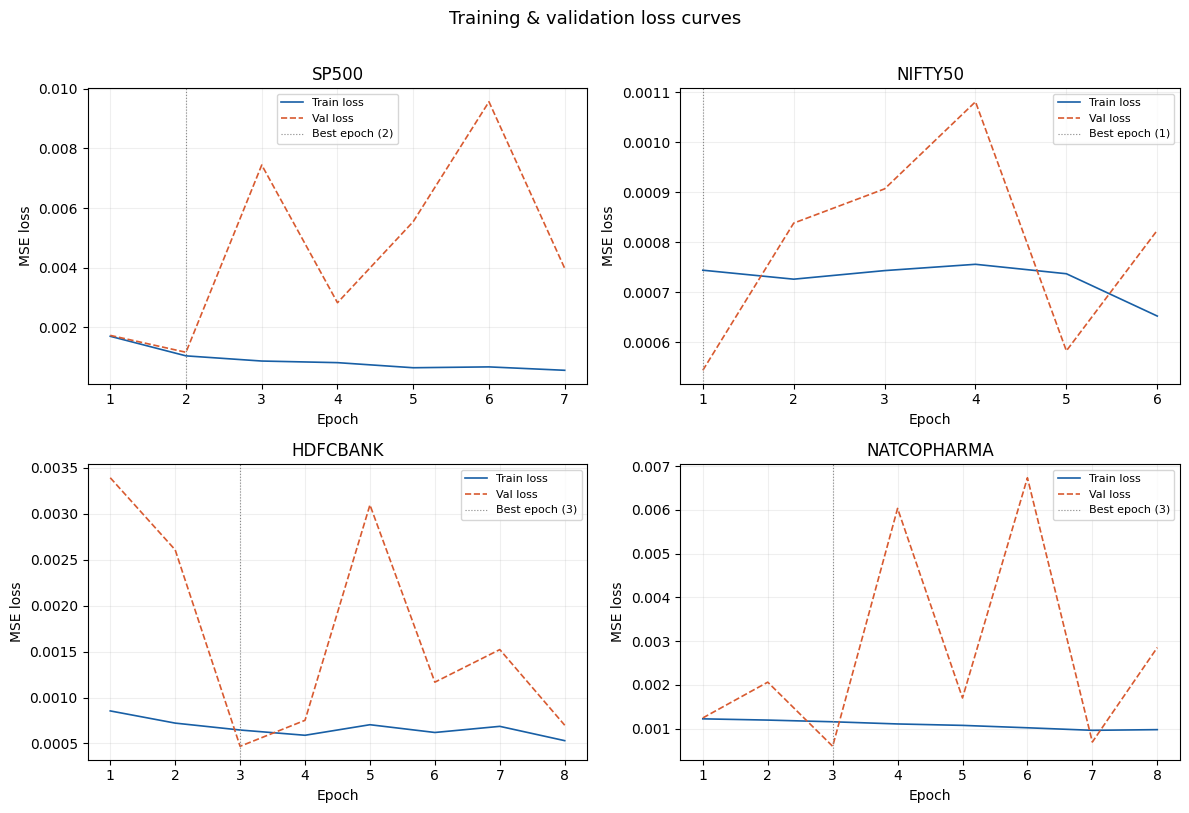

Fig 8 saved


In [9]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, name in zip(axes.flat, NAMES):
    hist     = histories[name]
    epochs   = range(1, len(hist['loss']) + 1)
    best_ep  = int(np.argmin(hist['val_loss'])) + 1

    ax.plot(epochs, hist['loss'],     lw=1.2,
            color='#185FA5', label='Train loss')
    ax.plot(epochs, hist['val_loss'], lw=1.2,
            color='#D85A30', label='Val loss', ls='--')
    ax.axvline(best_ep, color='#888', lw=0.8, ls=':',
               label=f'Best epoch ({best_ep})')
    ax.set_title(name, fontsize=12)
    ax.set_xlabel('Epoch'); ax.set_ylabel('MSE loss')
    ax.legend(fontsize=8); ax.grid(alpha=0.2)

plt.suptitle('Training & validation loss curves', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(f'{FIG_LOSS}/fig8_loss_curves.png', dpi=300, bbox_inches='tight')
plt.show()
print("Fig 8 saved")

## Evaluation function

In [10]:
def evaluate_model(model, X, y_scaled, scaler, label=''):
    """
    Predicts, inverse-transforms, computes MSE/RMSE/MAE/R².
    Returns dict of metrics and inverse-transformed arrays.
    """
    y_pred_scaled = model.predict(X, verbose=0)

    # Inverse transform — scaler was fit on (n_steps+1) columns
    # We only need to inverse the first column (Close_smoothed)
    n_cols   = scaler.n_features_in_
    pad_true = np.zeros((len(y_scaled), n_cols))
    pad_pred = np.zeros((len(y_pred_scaled), n_cols))
    pad_true[:, 0] = y_scaled.flatten()
    pad_pred[:, 0] = y_pred_scaled.flatten()

    y_true = scaler.inverse_transform(pad_true)[:, 0]
    y_pred = scaler.inverse_transform(pad_pred)[:, 0]

    mse  = float(mean_squared_error(y_true, y_pred))
    rmse = float(np.sqrt(mse))
    mae  = float(mean_absolute_error(y_true, y_pred))
    r2   = float(r2_score(y_true, y_pred))

    print(f"  {label:10s} → MSE={mse:.4f}  RMSE={rmse:.4f}  "
          f"MAE={mae:.4f}  R²={r2:.4f}")
    return {'mse': mse, 'rmse': rmse, 'mae': mae, 'r2': r2,
            'y_true': y_true, 'y_pred': y_pred}


print("Evaluation function defined")

Evaluation function defined


## Evaluate all models & build metrics table

In [11]:
metrics_rows = []

print("ES-LSTM Evaluation Results")
print("=" * 60)

for name in NAMES:
    print(f"\n{name}")
    X_train, X_test, y_train, y_test = prepared[name]
    model  = best_models[name]
    scaler = scalers[name]

    train_res = evaluate_model(model, X_train, y_train, scaler, 'Train')
    val_res   = evaluate_model(model, X_test,  y_test,  scaler, 'Val')

    for split, res in [('train', train_res), ('validation', val_res)]:
        metrics_rows.append({
            'dataset': name,
            'model':   'ES-LSTM',
            'split':   split,
            'mse':     round(res['mse'],  4),
            'rmse':    round(res['rmse'], 4),
            'mae':     round(res['mae'],  4),
            'r2':      round(res['r2'],   4),
        })

# Save metrics
metrics_df = pd.DataFrame(metrics_rows)
metrics_df.to_csv('../data/es_lstm_metrics.csv', index=False)
print("\n\nMetrics saved to data/es_lstm_metrics.csv")
print(metrics_df.to_string(index=False))

ES-LSTM Evaluation Results

SP500
  Train      → MSE=4749.2929  RMSE=68.9151  MAE=65.1394  R²=0.9949
  Val        → MSE=7412.9895  RMSE=86.0987  MAE=65.9984  R²=0.9676

NIFTY50
  Train      → MSE=39258.8699  RMSE=198.1385  MAE=157.9510  R²=0.9980
  Val        → MSE=69483.6156  RMSE=263.5974  MAE=215.0001  R²=0.9708

HDFCBANK
  Train      → MSE=17.4991  RMSE=4.1832  MAE=2.2488  R²=0.9997
  Val        → MSE=88.6905  RMSE=9.4176  MAE=6.3303  R²=0.9493

NATCOPHARMA
  Train      → MSE=92.9542  RMSE=9.6413  MAE=5.7777  R²=0.9990
  Val        → MSE=358.0863  RMSE=18.9232  MAE=12.8897  R²=0.9933


Metrics saved to data/es_lstm_metrics.csv
    dataset   model      split        mse     rmse      mae     r2
      SP500 ES-LSTM      train  4749.2929  68.9151  65.1394 0.9949
      SP500 ES-LSTM validation  7412.9895  86.0987  65.9984 0.9676
    NIFTY50 ES-LSTM      train 39258.8699 198.1385 157.9510 0.9980
    NIFTY50 ES-LSTM validation 69483.6156 263.5974 215.0001 0.9708
   HDFCBANK ES-LSTM      t

## Fig 9: Actual vs predicted

             → MSE=7412.9895  RMSE=86.0987  MAE=65.9984  R²=0.9676
             → MSE=69483.6156  RMSE=263.5974  MAE=215.0001  R²=0.9708
             → MSE=88.6905  RMSE=9.4176  MAE=6.3303  R²=0.9493
             → MSE=358.0863  RMSE=18.9232  MAE=12.8897  R²=0.9933


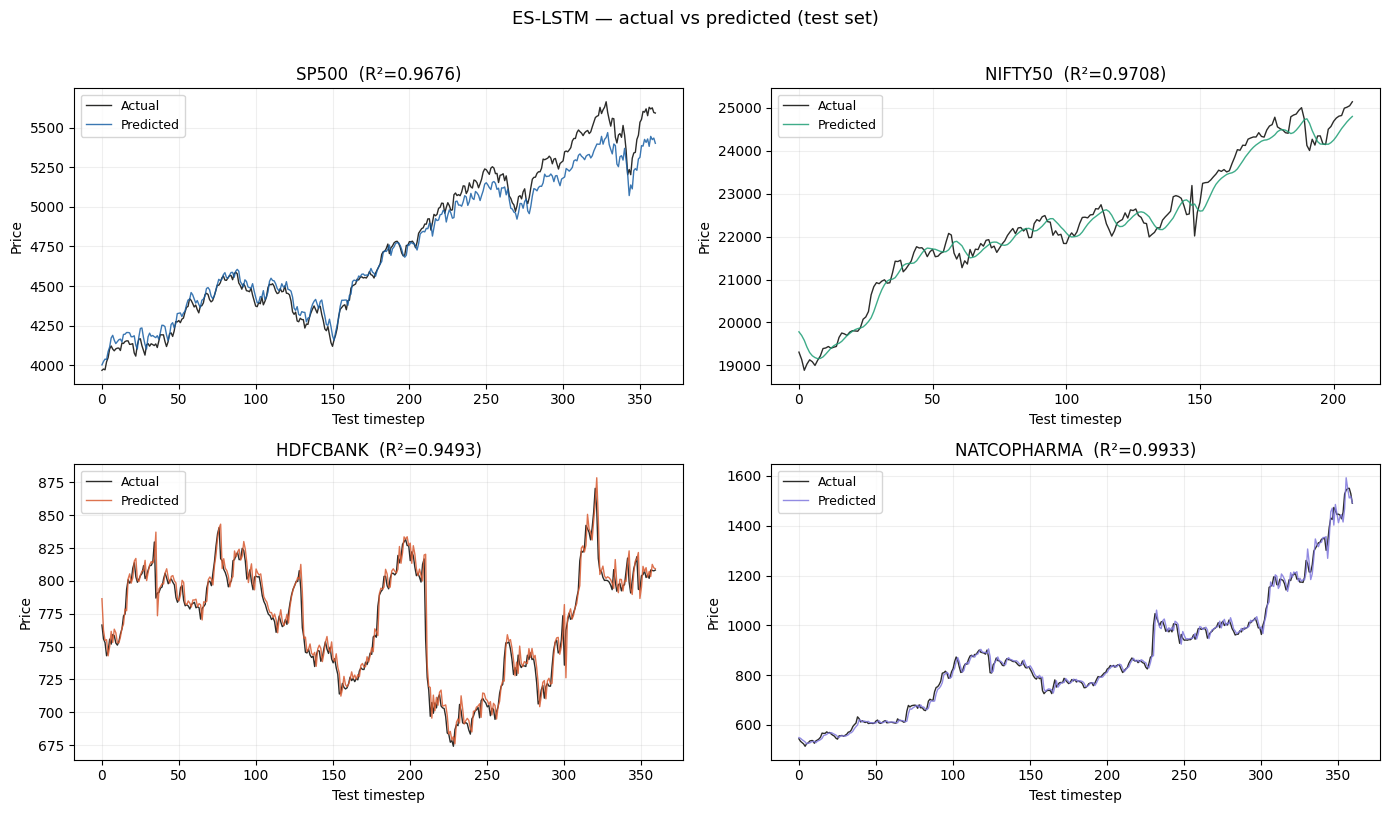

Fig 9 saved


In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
colors = ['#185FA5', '#1D9E75', '#D85A30', '#7F77DD']

for ax, name, color in zip(axes.flat, NAMES, colors):
    X_train, X_test, y_train, y_test = prepared[name]
    model  = best_models[name]
    scaler = scalers[name]

    res    = evaluate_model(model, X_test, y_test, scaler)
    r2_val = r2_score(res['y_true'], res['y_pred'])

    ax.plot(res['y_true'], lw=1.0, color='#2C2C2A', label='Actual')
    ax.plot(res['y_pred'], lw=1.0, color=color,
            label='Predicted', alpha=0.85)
    ax.set_title(f'{name}  (R²={r2_val:.4f})', fontsize=12)
    ax.set_xlabel('Test timestep')
    ax.set_ylabel('Price')
    ax.legend(fontsize=9); ax.grid(alpha=0.2)

plt.suptitle('ES-LSTM — actual vs predicted (test set)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(f'{FIG_PRED}/fig9_actual_vs_predicted.png',
            dpi=300, bbox_inches='tight')
plt.show()
print("Fig 9 saved")

##  Fig 10: Best hyperparameters table

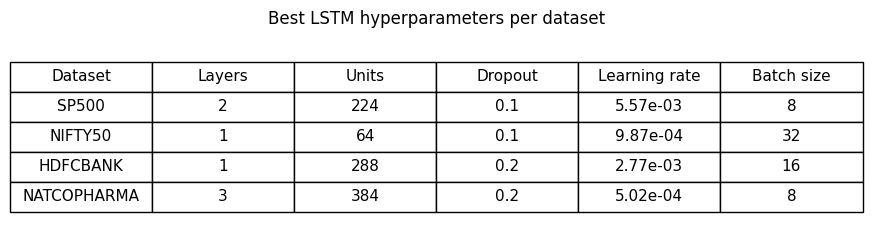

Fig 10 saved


In [13]:
fig, ax = plt.subplots(figsize=(11, 2.5))
ax.axis('off')

rows = []
for name in NAMES:
    hp = best_hps[name]
    rows.append([
        name,
        hp.get('n_layers', '—'),
        hp.get('units',    '—'),
        f"{hp.get('dropout', 0):.1f}",
        f"{hp.get('lr', 0):.2e}",
        hp.get('batch_size', '—'),
    ])

cols = ['Dataset', 'Layers', 'Units', 'Dropout', 'Learning rate', 'Batch size']
tbl  = ax.table(cellText=rows, colLabels=cols,
                loc='center', cellLoc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.scale(1, 1.8)

plt.title('Best LSTM hyperparameters per dataset',
          fontsize=12, pad=12)
plt.savefig(f'{FIG_PRED}/fig10_best_hyperparams.png',
            dpi=300, bbox_inches='tight')
plt.show()
print("Fig 10 saved")

## Markdown summary

## LSTM Training Summary

- All four models trained with Keras Tuner RandomSearch (10 trials)
- Early stopping with patience=5 prevented overfitting
- Best models saved to models/*_best/model.keras
- Metrics saved to data/es_lstm_metrics.csv
- Processed arrays saved to data/processed/*.npy for baselines notebook

### Target metrics from paper (validation)
| Dataset     | MSE    | RMSE   | MAE    | R²     |
|-------------|--------|--------|--------|--------|
| S&P 500     | 0.0018 | 0.0419 | 0.0322 | 0.9503 |
| NIFTY 50    | 0.0019 | 0.0434 | 0.0323 | 0.8983 |
| HDFC Bank   | 0.0042 | 0.0645 | 0.0446 | 0.9519 |
| Natco Pharma| 0.0057 | 0.0757 | 0.0494 | 0.9337 |

Proceed to: `04_baselines.ipynb`